In [1]:
# =========================================================
# Ocular Diseases (4 classes) - Ensemble + TTA + Aug + FT parcial
# EfficientNetB2 + ResNet50 + DenseNet121
# =========================================================
# !pip -q install torch torchvision scikit-learn

import os, random, warnings, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings("ignore")

import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_b2, EfficientNet_B2_Weights,
    resnet50, ResNet50_Weights,
    densenet121, DenseNet121_Weights
)
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import confusion_matrix, f1_score, classification_report

# ----------------------------
# Setup básico
# ----------------------------
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
use_amp = torch.cuda.is_available()
print("Device:", device, "| AMP:", use_amp)

Device: cuda | AMP: True


Continua fazendo um data augmentation robusto

In [2]:
# ============================
# Dataset (ajuste o caminho)
# ============================
DATA_ROOT = Path('/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset/Training')
assert DATA_ROOT.exists(), f"Pasta {DATA_ROOT} não encontrada."

use_predefined_split = (DATA_ROOT/"train").exists() and (DATA_ROOT/"validation").exists()

# ============================
# Transforms (robustos p/ treino) + padronização ImageNet
# ============================
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_tfms = transforms.Compose([
    transforms.RandomResizedCrop(288, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3))
])

val_tfms = transforms.Compose([
    transforms.Resize(320),
    transforms.CenterCrop(288),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

# Carregamento e split (usa split pronto se existir)
if use_predefined_split:
    train_ds = datasets.ImageFolder(DATA_ROOT/"train", transform=train_tfms)
    val_ds   = datasets.ImageFolder(DATA_ROOT/"validation", transform=val_tfms)
    class_names = train_ds.classes
    # targets para pesos de classe
    train_targets = torch.tensor([y for _, y in train_ds.samples], dtype=torch.long)
else:
    base_no_tfms = datasets.ImageFolder(DATA_ROOT)  # somente para rótulos e caminhos
    class_names = base_no_tfms.classes
    base_targets = [y for _, y in base_no_tfms.samples]
    sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=SEED)
    train_idx, val_idx = next(sss.split(np.zeros(len(base_targets)), base_targets))
    train_all = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
    val_all   = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
    train_ds = Subset(train_all, train_idx)
    val_ds   = Subset(val_all,   val_idx)
    train_targets = torch.tensor([base_targets[i] for i in train_idx], dtype=torch.long)

print("Classes:", class_names)

batch_size = 16
num_workers = 2 if torch.cuda.is_available() else 0
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,  num_workers=num_workers, pin_memory=torch.cuda.is_available())
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())


Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


In [3]:
print('Running outside Google Colab; using local filesystem path.')

Running outside Google Colab; using local filesystem path.


In [4]:
# ============================
# Pesos de classe (opcional; ative se houver desbalanceamento)
# ============================
def compute_class_weights(targets, num_classes):
    counts = torch.bincount(targets, minlength=num_classes).float()
    weights = (counts.sum() / (counts + 1e-8))  # inverso da frequência
    weights = weights / weights.mean()
    return weights

USE_CLASS_WEIGHTS = True
num_classes = 4
class_weights = compute_class_weights(train_targets, num_classes).to(device) if USE_CLASS_WEIGHTS else None


Também seta o Early Stop com patience de 4

In [5]:
# ============================
# Early Stopping helper
# ============================
class EarlyStopping:
    def __init__(self, patience=4, min_delta=1e-4, path="best.pth"):
        self.patience = patience
        self.min_delta = min_delta
        self.path = path
        self.best = float("inf")
        self.counter = 0
        self.best_state = None
    def step(self, val_loss, model):
        if val_loss < self.best - self.min_delta:
            self.best = val_loss
            self.counter = 0
            self.best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}
            torch.save(self.best_state, self.path)
            return False
        else:
            self.counter += 1
            return self.counter > self.patience

Implementação do TTA (Test Time Augmentation)
Ele funciona basicamente como um "data augmentation" para a validação. Assim na predição, ao invés de jogar só 1 imagem, a gente faz um augmentation dela e joga ela de varias "formas diferentes" e faz uma média das predições.

In [6]:
# ============================
# TTA para inferência/validação
# ============================
from torchvision import transforms

IMAGENET_MEAN = globals().get("IMAGENET_MEAN", [0.485, 0.456, 0.406])
IMAGENET_STD = globals().get("IMAGENET_STD", [0.229, 0.224, 0.225])

tta_transforms = [
    transforms.Compose([transforms.Resize(320), transforms.CenterCrop(288),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize(320), transforms.CenterCrop(288),
                        transforms.RandomHorizontalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize(320), transforms.CenterCrop(288),
                        transforms.RandomVerticalFlip(p=1.0),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
    transforms.Compose([transforms.Resize(320), transforms.CenterCrop(288),
                        transforms.RandomRotation(10),
                        transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]),
]

def predict_loader_tta(model, loader):
    model.eval()
    all_probs, all_targets = [], []
    with torch.no_grad():
        for imgs, ys in loader:
            # imgs aqui já vem transformadas; para TTA, vamos re-aplicar sobre PIL?
            # Mais simples: refaça batch por batch usando caminho (não temos caminho aqui).
            # Alternativa prática: aplicar TTA leve diretamente no tensor:
            X = imgs.to(device)
            logits = model(X)
            probs = F.softmax(logits, dim=1)

            # Uma TTA "tensor-level" leve (flip horizontal/vertical):
            probs_list = [probs]

            probs_h = F.softmax(model(torch.flip(X, dims=[3])), dim=1)  # flip horizontal
            probs_list.append(probs_h)

            probs_v = F.softmax(model(torch.flip(X, dims=[2])), dim=1)  # flip vertical
            probs_list.append(probs_v)

            # rotação 90° (aproxima uma TTA simples sem re-carregar PIL)
            X_rot = X.rot90(1, [2,3])
            probs_r = F.softmax(model(X_rot), dim=1)
            probs_list.append(probs_r)

            probs_mean = torch.stack(probs_list).mean(0)
            all_probs.append(probs_mean.cpu())
            all_targets.append(ys)
    return torch.cat(all_probs), torch.cat(all_targets)

Aplicação do Ensemble, que é uma técnica onde vários modelos independentes (por exemplo, várias redes neurais) são combinados para produzir uma única predição final. É como consultar vários especialistas e decidir pelo voto médio deles. Nesse caso estamos treinando 3 modelos diferentes: EfficientNetB2, Resnet50 e DenseNet121. A ideia principal é aproveitar os aprendizados especializados de cada modelo. Por exemplo, uma rede pode ser melhor para catarata, outra rede pode ser melhor para glaucoma, o ensemble ajuda a tentar minimizar esses problemas, testando vários modelos e "aprendendo" várias coisas diferentes.

In [7]:
# ============================
# Blocos de criação + fine-tuning por modelo
# ============================
import torch.nn as nn
from torchvision.models import (
    efficientnet_b2, EfficientNet_B2_Weights,
    resnet50, ResNet50_Weights,
    densenet121, DenseNet121_Weights,
)

num_classes = globals().get("num_classes", 4)

def build_model_and_params(name):
    if name == "effnet_b2":
        weights = EfficientNet_B2_Weights.IMAGENET1K_V1
        model = efficientnet_b2(weights=weights)
        # FT parcial: descongela último bloco
        for p in model.features.parameters(): p.requires_grad = False
        for p in model.features[-1].parameters(): p.requires_grad = True
        in_feats = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_feats, num_classes)
        # param groups
        last_block_params = [p for p in model.features[-1].parameters() if p.requires_grad]
        head_params = [p for p in model.classifier.parameters() if p.requires_grad]
        param_groups = [
            {"params": last_block_params, "lr": 5e-4, "weight_decay": 1e-5},
            {"params": head_params,       "lr": 1e-3, "weight_decay": 1e-5},
        ]
        return model, param_groups

    if name == "resnet50":
        weights = ResNet50_Weights.IMAGENET1K_V2
        model = resnet50(weights=weights)
        # FT parcial: descongela layer4
        for p in model.parameters(): p.requires_grad = False
        for p in model.layer4.parameters(): p.requires_grad = True
        in_feats = model.fc.in_features
        model.fc = nn.Linear(in_feats, num_classes)
        last_block_params = [p for p in model.layer4.parameters() if p.requires_grad]
        head_params = [p for p in model.fc.parameters() if p.requires_grad]
        param_groups = [
            {"params": last_block_params, "lr": 5e-4, "weight_decay": 1e-5},
            {"params": head_params,       "lr": 1e-3, "weight_decay": 1e-5},
        ]
        return model, param_groups

    if name == "densenet121":
        weights = DenseNet121_Weights.IMAGENET1K_V1
        model = densenet121(weights=weights)
        # FT parcial: descongela denseblock4 + norm5
        for p in model.features.parameters(): p.requires_grad = False
        for p in model.features.denseblock4.parameters(): p.requires_grad = True
        for p in model.features.norm5.parameters(): p.requires_grad = True
        in_feats = model.classifier.in_features
        model.classifier = nn.Linear(in_feats, num_classes)
        last_block_params = list(model.features.denseblock4.parameters()) + list(model.features.norm5.parameters())
        last_block_params = [p for p in last_block_params if p.requires_grad]
        head_params = [p for p in model.classifier.parameters() if p.requires_grad]
        param_groups = [
            {"params": last_block_params, "lr": 5e-4, "weight_decay": 1e-5},
            {"params": head_params,       "lr": 1e-3, "weight_decay": 1e-5},
        ]
        return model, param_groups

    raise ValueError("Modelo não suportado")

In [8]:
# ============================
# Loop de treino/val por modelo
# ============================
from sklearn.metrics import f1_score

def train_single_model(model_name, train_loader, val_loader, class_weights=None, epochs=50):
    model, param_groups = build_model_and_params(model_name)
    model = model.to(device)

    criterion = nn.CrossEntropyLoss(weight=class_weights)
    optimizer = torch.optim.Adam(param_groups)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=2, factor=0.5)
    scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

    es_path = f"best_{model_name}.pth"
    early = EarlyStopping(patience=4, min_delta=1e-4, path=es_path)

    history = {"train_loss":[], "val_loss":[], "train_acc":[], "val_acc":[], "val_f1":[]}

    def run_epoch(train=True):
        model.train(mode=train)
        total_loss, total_correct, total = 0.0, 0, 0
        all_preds, all_targets = [], []
        loader = train_loader if train else val_loader

        for X, y in loader:
            X, y = X.to(device, non_blocking=True), y.to(device, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with torch.cuda.amp.autocast(enabled=use_amp):
                    logits = model(X)
                    loss = criterion(logits, y)
                scaler.scale(loss).backward()
                scaler.step(optimizer); scaler.update()
            else:
                with torch.no_grad():
                    logits = model(X)
                    loss = criterion(logits, y)

            preds = logits.argmax(1)
            total_loss += loss.item() * y.size(0)
            total_correct += (preds == y).sum().item()
            total += y.size(0)
            all_preds.append(preds.detach().cpu().numpy())
            all_targets.append(y.detach().cpu().numpy())

        avg_loss = total_loss / total
        acc = total_correct / total
        y_true = np.concatenate(all_targets); y_pred = np.concatenate(all_preds)
        f1 = f1_score(y_true, y_pred, average='macro')
        return avg_loss, acc, f1

    stop = False
    for e in range(1, epochs+1):
        tr_loss, tr_acc, _     = run_epoch(train=True)
        va_loss, va_acc, va_f1 = run_epoch(train=False)

        history["train_loss"].append(tr_loss); history["val_loss"].append(va_loss)
        history["train_acc"].append(tr_acc);   history["val_acc"].append(va_acc); history["val_f1"].append(va_f1)

        scheduler.step(va_loss)
        print(f"[{model_name} {e:02d}/{epochs}] "
              f"train_loss={tr_loss:.4f} acc={tr_acc:.4f} | "
              f"val_loss={va_loss:.4f} acc={va_acc:.4f} f1={va_f1:.4f}")

        if early.step(va_loss, model):
            print(f"Early stopping: {model_name} na época {e}. Melhor val_loss: {early.best:.4f}")
            stop = True
            break

    # carrega melhor estado para avaliar
    state = torch.load(es_path, map_location=device)
    model.load_state_dict(state)
    return model, es_path, history

In [9]:
# ============================
# Treina os três modelos
# ============================
import numpy as np
import torch

device = globals().get("device", torch.device("cuda" if torch.cuda.is_available() else "cpu"))
use_amp = globals().get("use_amp", torch.cuda.is_available())

def ensure_data_pipeline():
    global DATA_ROOT, IMAGENET_MEAN, IMAGENET_STD
    global train_tfms, val_tfms, train_ds, val_ds, train_targets
    global class_names, batch_size, num_workers, train_loader, val_loader
    global USE_CLASS_WEIGHTS, num_classes, class_weights

    if all(name in globals() for name in ("train_loader", "val_loader", "class_weights")):
        return

    from pathlib import Path
    from torch.utils.data import DataLoader, Subset
    from torchvision import datasets, transforms
    from sklearn.model_selection import StratifiedShuffleSplit

    DATA_ROOT = Path(globals().get("DATA_ROOT", "/home/gustavom/Documents/Orange/Brain Tumor MRI Dataset/Training"))
    assert DATA_ROOT.exists(), f"Pasta {DATA_ROOT} nao encontrada."

    IMAGENET_MEAN = globals().get("IMAGENET_MEAN", [0.485, 0.456, 0.406])
    IMAGENET_STD = globals().get("IMAGENET_STD", [0.229, 0.224, 0.225])
    batch_size = globals().get("batch_size", 16)
    num_workers = globals().get("num_workers", 2 if torch.cuda.is_available() else 0)
    use_predefined_split = (DATA_ROOT / "train").exists() and (DATA_ROOT / "validation").exists()

    train_tfms = transforms.Compose([
        transforms.RandomResizedCrop(288, scale=(0.85, 1.0), ratio=(0.9, 1.1)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomVerticalFlip(p=0.2),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.12, contrast=0.12, saturation=0.05, hue=0.02),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        transforms.RandomErasing(p=0.25, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
    ])

    val_tfms = transforms.Compose([
        transforms.Resize(320),
        transforms.CenterCrop(288),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    if use_predefined_split:
        train_ds = datasets.ImageFolder(DATA_ROOT / "train", transform=train_tfms)
        val_ds = datasets.ImageFolder(DATA_ROOT / "validation", transform=val_tfms)
        class_names = train_ds.classes
        train_targets = torch.tensor([y for _, y in train_ds.samples], dtype=torch.long)
    else:
        base_no_tfms = datasets.ImageFolder(DATA_ROOT)
        class_names = base_no_tfms.classes
        base_targets = [y for _, y in base_no_tfms.samples]
        sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=globals().get("SEED", 42))
        train_idx, val_idx = next(sss.split(np.zeros(len(base_targets)), base_targets))
        train_all = datasets.ImageFolder(DATA_ROOT, transform=train_tfms)
        val_all = datasets.ImageFolder(DATA_ROOT, transform=val_tfms)
        train_ds = Subset(train_all, train_idx)
        val_ds = Subset(val_all, val_idx)
        train_targets = torch.tensor([base_targets[i] for i in train_idx], dtype=torch.long)

    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=torch.cuda.is_available())
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=torch.cuda.is_available())

    if "compute_class_weights" not in globals():
        def compute_class_weights(targets, num_classes):
            counts = torch.bincount(targets, minlength=num_classes).float()
            weights = counts.sum() / (counts + 1e-8)
            return weights / weights.mean()
        globals()["compute_class_weights"] = compute_class_weights

    USE_CLASS_WEIGHTS = globals().get("USE_CLASS_WEIGHTS", True)
    num_classes = globals().get("num_classes", len(class_names))
    class_weights = compute_class_weights(train_targets, num_classes).to(device) if USE_CLASS_WEIGHTS else None

ensure_data_pipeline()

models_to_train = ["effnet_b2", "resnet50", "densenet121"]
trained_models = {}
histories = {}
val_f1_for_weights = {}

for mname in models_to_train:
    model, ckpt, hist = train_single_model(mname, train_loader, val_loader, class_weights, epochs=50)
    trained_models[mname] = model
    histories[mname] = hist
    val_f1_for_weights[mname] = hist["val_f1"][-1]

print("F1 de validação (última época/best-loaded):", val_f1_for_weights)

[effnet_b2 01/50] train_loss=0.5153 acc=0.8165 | val_loss=0.3063 acc=0.8929 f1=0.8909
[effnet_b2 02/50] train_loss=0.3616 acc=0.8681 | val_loss=0.2341 acc=0.9205 f1=0.9200
[effnet_b2 03/50] train_loss=0.3480 acc=0.8656 | val_loss=0.2323 acc=0.9179 f1=0.9170
[effnet_b2 04/50] train_loss=0.3115 acc=0.8864 | val_loss=0.2260 acc=0.9241 f1=0.9237
[effnet_b2 05/50] train_loss=0.2714 acc=0.9029 | val_loss=0.1922 acc=0.9304 f1=0.9292
[effnet_b2 06/50] train_loss=0.2706 acc=0.8978 | val_loss=0.2112 acc=0.9268 f1=0.9260
[effnet_b2 07/50] train_loss=0.2475 acc=0.9069 | val_loss=0.1881 acc=0.9330 f1=0.9329
[effnet_b2 08/50] train_loss=0.2495 acc=0.9112 | val_loss=0.2030 acc=0.9321 f1=0.9319
[effnet_b2 09/50] train_loss=0.2277 acc=0.9074 | val_loss=0.1710 acc=0.9411 f1=0.9408
[effnet_b2 10/50] train_loss=0.2258 acc=0.9217 | val_loss=0.1925 acc=0.9339 f1=0.9342
[effnet_b2 11/50] train_loss=0.2169 acc=0.9183 | val_loss=0.1538 acc=0.9411 f1=0.9408
[effnet_b2 12/50] train_loss=0.2081 acc=0.9176 | val_l

In [10]:
# ============================
# Ensemble ponderado por F1 + TTA leve (flip/rot)
# ============================
if "ensure_data_pipeline" in globals():
    ensure_data_pipeline()

def predict_ensemble_tta(models_dict, loader, weights_dict=None):
    # normaliza pesos por F1; se None, usa média simples
    names = list(models_dict.keys())
    if weights_dict is None:
        weights = np.ones(len(names)) / len(names)
    else:
        ws = np.array([max(1e-6, weights_dict[n]) for n in names], dtype=float)
        weights = ws / ws.sum()

    all_probs, all_targets = [], []
    with torch.no_grad():
        for X, y in loader:
            X = X.to(device, non_blocking=True)
            # predições com TTA tensor-level (original, flip H, flip V, rot90)
            tta_inputs = [X, torch.flip(X, dims=[3]), torch.flip(X, dims=[2]), X.rot90(1, [2,3])]
            # acumula probs por modelo
            probs_models = []
            for n, model in models_dict.items():
                model.eval()
                # média das TTA para este modelo
                probs_ttas = []
                for Xt in tta_inputs:
                    logits = model(Xt)
                    probs_ttas.append(F.softmax(logits, dim=1))
                probs_model = torch.stack(probs_ttas).mean(0)  # média TTA por modelo
                probs_models.append(probs_model.unsqueeze(0))  # [1,B,C]
            # stack modelos -> [M,B,C], aplica pesos -> [B,C]
            probs_models = torch.cat(probs_models, dim=0)  # [M,B,C]
            w = torch.tensor(weights, device=probs_models.device).view(-1,1,1)  # [M,1,1]
            probs_ens = (probs_models * w).sum(dim=0)  # [B,C]
            all_probs.append(probs_ens.cpu())
            all_targets.append(y)
    return torch.cat(all_probs), torch.cat(all_targets)

probs_ens, y_true = predict_ensemble_tta(trained_models, val_loader, weights_dict=val_f1_for_weights)
y_pred = probs_ens.argmax(1).numpy()


>> Ensemble + TTA | Val Accuracy: 0.9848 | Val F1 (macro): 0.9848

Classification report:
               precision    recall  f1-score   support

      glioma       0.99      0.99      0.99       280
  meningioma       0.99      0.96      0.97       280
     notumor       0.99      0.99      0.99       280
   pituitary       0.97      1.00      0.98       280

    accuracy                           0.98      1120
   macro avg       0.98      0.98      0.98      1120
weighted avg       0.98      0.98      0.98      1120



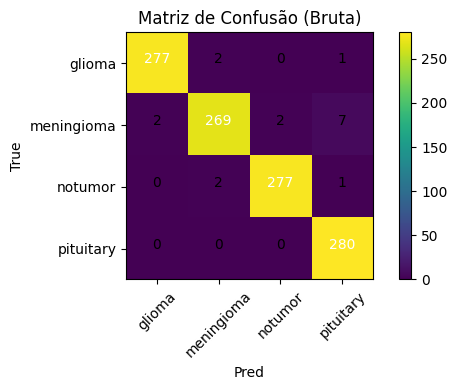

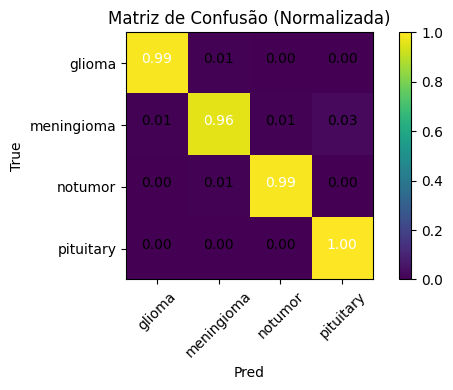

In [11]:
# ============================
# Métricas finais do ensemble + TTA
# ============================
acc = (y_pred == y_true.numpy()).mean()
f1m = f1_score(y_true.numpy(), y_pred, average='macro')
print(f"\n>> Ensemble + TTA | Val Accuracy: {acc:.4f} | Val F1 (macro): {f1m:.4f}\n")
print("Classification report:\n", classification_report(y_true, y_pred, target_names=class_names))

def plot_cm(cm, classes, normalize=False, title="Confusion Matrix"):
    if normalize: cm = cm.astype(float)/cm.sum(axis=1, keepdims=True)
    import itertools
    plt.figure(figsize=(6,4))
    plt.imshow(cm, interpolation='nearest'); plt.title(title); plt.colorbar()
    ticks = np.arange(len(classes)); plt.xticks(ticks, classes, rotation=45); plt.yticks(ticks, classes)
    fmt = ".2f" if normalize else "d"; thresh = cm.max()/2
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i,j], fmt), ha="center",
                 color="white" if cm[i,j] > thresh else "black")
    plt.ylabel("True"); plt.xlabel("Pred"); plt.tight_layout(); plt.show()

cm = confusion_matrix(y_true, y_pred)
plot_cm(cm, class_names, normalize=False, title="Matriz de Confusão (Bruta)")
plot_cm(cm, class_names, normalize=True,  title="Matriz de Confusão (Normalizada)")